In [95]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vedantshinde16/car-dekho/cardekho_dataset.csv


In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px
import warnings
from six.moves import urllib


warnings.filterwarnings("ignore")

%matplotlib inline

In [97]:
df = pd.read_csv('/kaggle/input/datasets/vedantshinde16/car-dekho/cardekho_dataset.csv')

# Overview of CarDekho 


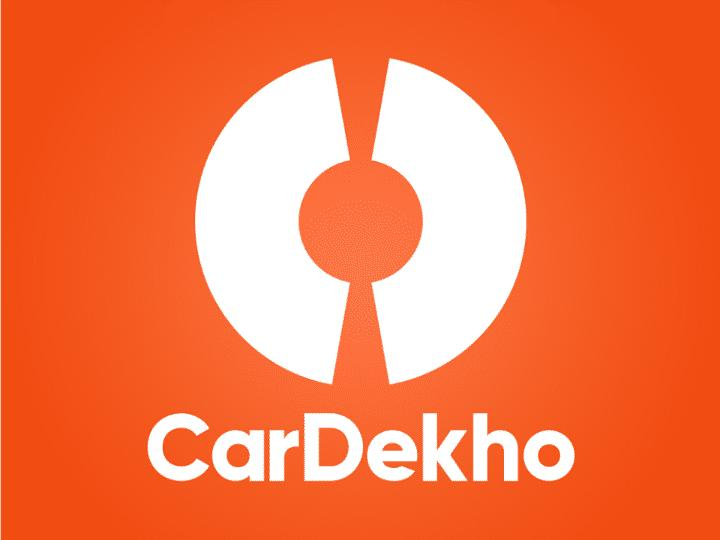!
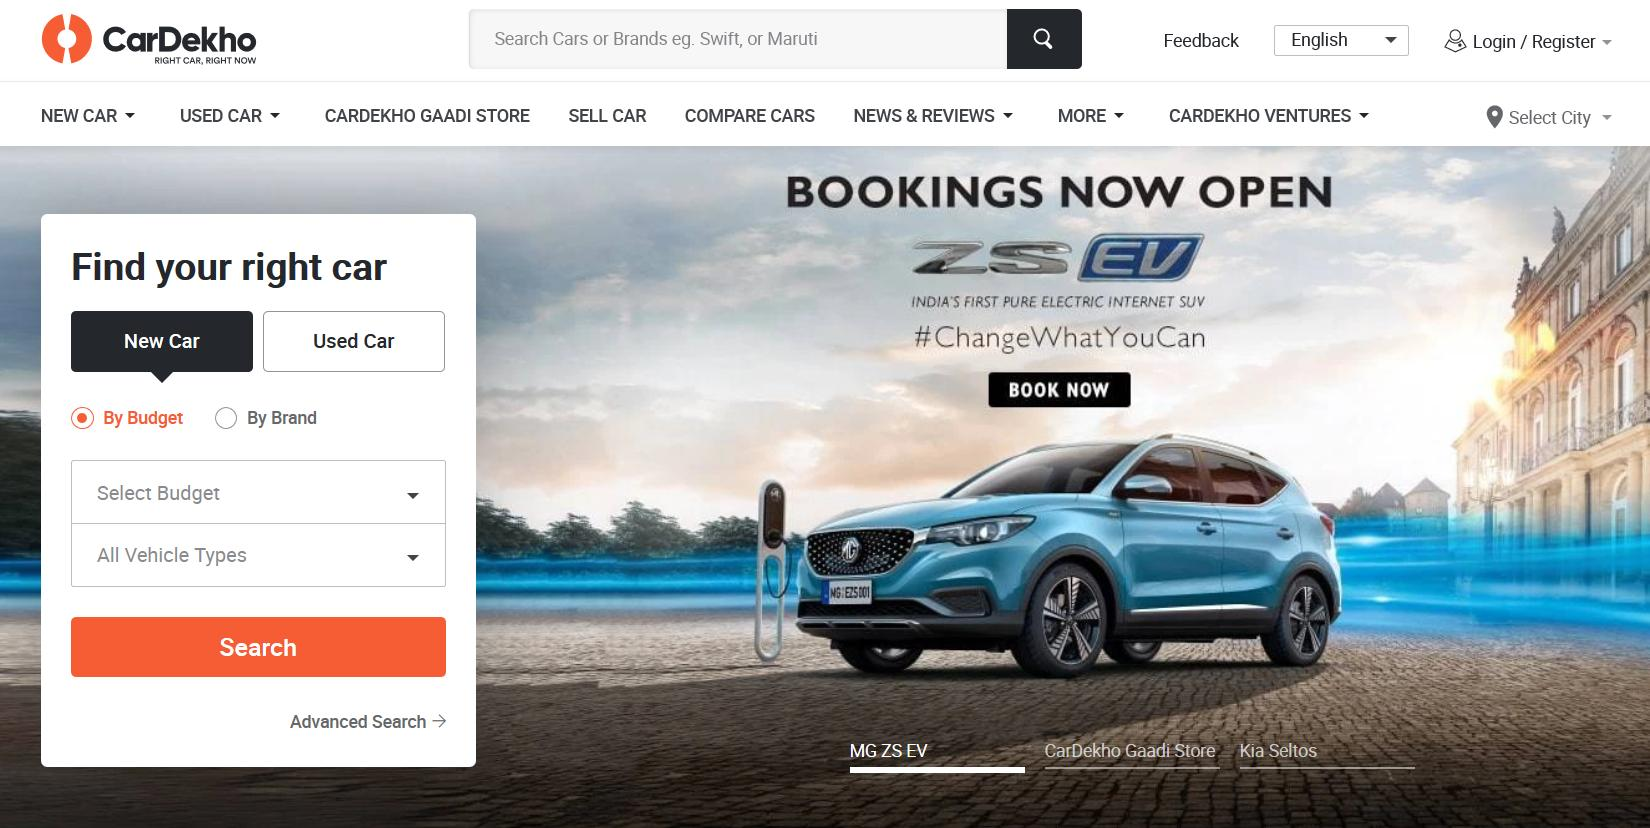!


CarDekho is one of India’s leading online platforms for buying and selling new and used cars. Founded in 2008 and headquartered in Jaipur, it is part of the parent company GirnarSoft


CarDekho is a leading online automotive platform in India that helps users buy, sell, and research cars in a simple and efficient way. Founded in 2008 and headquartered in Jaipur, it provides detailed information about new and used cars, including prices, features, specifications, reviews, and comparisons. The platform also offers services like car loans, insurance, and dealer connections, making the entire car-buying journey convenient. With its user-friendly website and mobile app, CarDekho has become a trusted choice for millions of users across India and other countries.

🔹 Short Points
🚘 Online platform for buying and selling cars
📊 Provides car details, comparisons, and reviews
🔁 Offers both new and used car listings
💰 Includes loan, EMI, and insurance services
📱 Easy-to-use website and mobile app
🌍 Operates in India and international markets




In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px
import warnings
from six.moves import urllib


warnings.filterwarnings("ignore")

%matplotlib inline

In [99]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [100]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

The dataset contains no missing (null) values, indicating a high level of data completeness and reliability.

In [101]:
df.shape

(15411, 14)

* Dataset contains approximately 15,411 rows
* Total of 14 columns/features
* Provides a large and structured data source for analysis
* Suitable for identifying patterns and trends
* Enables meaningful insights across multiple variables


## 📊 CarDekho Dataset – Data Card

* **car_name**: Name of the car (brand + model combined)
* **brand**: Car manufacturer (e.g., Maruti, Hyundai)
* **model**: Specific model of the car
* **vehicle_age**: Age of the vehicle in years
* **km_driven**: Total distance driven (in kilometers)
* **seller_type**: Type of seller (Dealer / Individual / Other)
* **fuel_type**: Fuel used (Petrol, Diesel, etc.)
* **transmission_type**: Transmission type (Manual / Automatic)
* **mileage**: Fuel efficiency of the car (km/l)
* **engine**: Engine capacity (in CC)
* **max_power**: Maximum power of the car (in bhp)
* **seats**: Seating capacity of the car
* **selling_price**: Price at which the car is listed/sold
## 🔹 Dataset Overview
Total Rows: ~15,411

Total Columns: 14

No missing or mismatched values

Well-structured dataset suitable for analysis and modeling


### 🔹 Key Highlights

* Most cars belong to **Maruti and Hyundai brands**
* Majority listings are **manual transmission vehicles**
* Fuel types are mainly **Petrol and Diesel**
* Most cars have **5 seating capacity**
* Prices vary widely, indicating a mix of **budget to premium cars**


In [102]:
df.duplicated().sum()

np.int64(0)

Dataset is free from duplicacy issue

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


* The dataset consists of **8 numerical columns** and **6 categorical (textual) columns**, providing a balanced structure for both statistical analysis and categorical insights.

* The dataset shows **minor completeness issues**, but they are not significant and can be handled effectively without impacting the overall analysis.

In [104]:
# seeking description 

df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


* The vehicle age in the dataset ranges from **1 to 29 years**, indicating a diverse mix of both relatively new and older cars.

* This suggests that the dataset includes **well-maintained older vehicles**, which are often more **cost-efficient and budget-friendly options** for buyers.


In [105]:
df.groupby('transmission_type')['selling_price'].mean()

transmission_type
Automatic    1.579557e+06
Manual       5.652852e+05
Name: selling_price, dtype: float64

* The dataset shows a higher proportion of **manual transmission vehicles** compared to automatic vehicles.

* This indicates that manual cars dominate the dataset, reflecting their **greater availability and popularity** in the market.


# Transmission vs Selling Price (step 1)

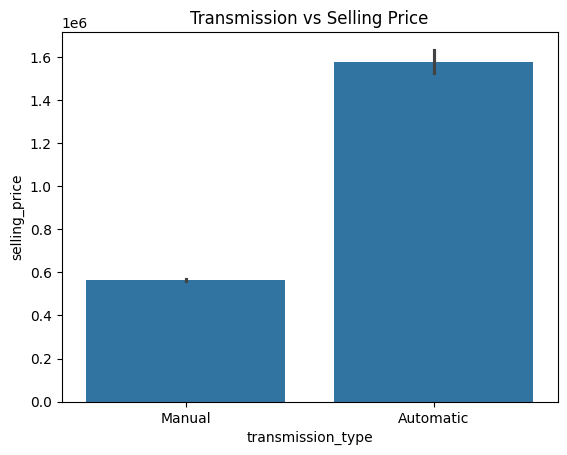

In [106]:
sns.barplot(x='transmission_type', y='selling_price', data=df)
plt.title("Transmission vs Selling Price")
plt.show()

--Compares average price by transmission

--Automatic cars usually priced higher

--Shows premium for convenience

# Kms Driven vs Selling Price (Step 2)

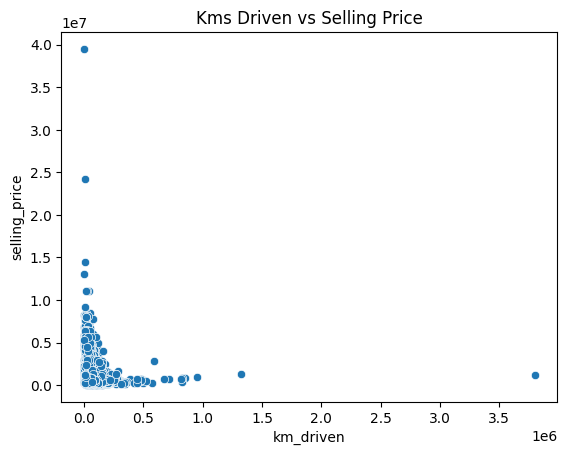

In [107]:
sns.scatterplot(x='km_driven', y='selling_price', data=df)
plt.title("Kms Driven vs Selling Price")
plt.show()

--Shows negative correlation

--Higher mileage → lower price

--Indicates wear & tear impact

# Fuel Type Impact (step3)

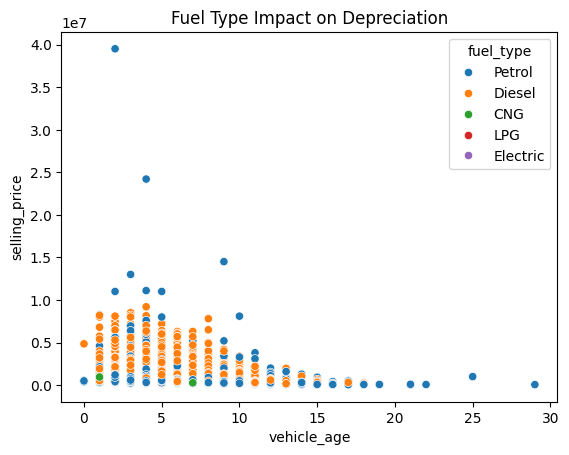

In [108]:
sns.scatterplot(x='vehicle_age', y='selling_price', hue='fuel_type', data=df)
plt.title("Fuel Type Impact on Depreciation")
plt.show()

--Shows how fuel type affects price drop

--Diesel cars retain value better

# Selling Price Distribution

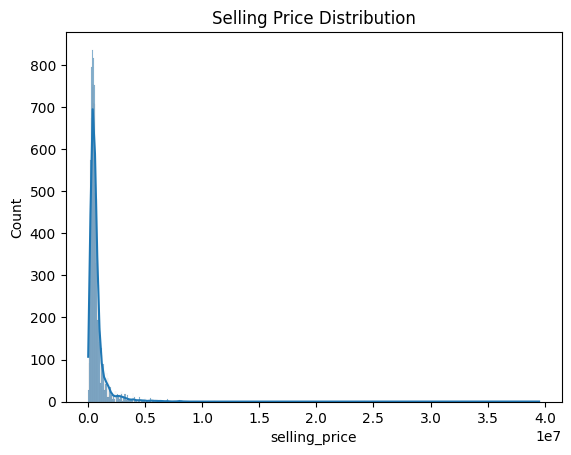

In [109]:
sns.histplot(df['selling_price'], kde=True)
plt.title("Selling Price Distribution")
plt.show()

--Shows how car selling prices are spread

--Helps identify skewness (usually right-skewed)

--Detects high-price outliers

--Most cars lie in lower-mid price range

# Car Age Distribution

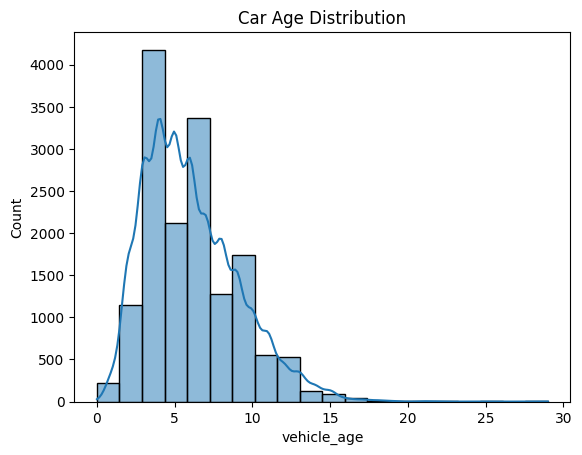

In [110]:
sns.histplot(df['vehicle_age'], bins=20, kde=True)
plt.title("Car Age Distribution")
plt.show()

--Shows how old cars are in dataset

--Helps identify majority age group

--Detects presence of very old cars (outliers)

# fuel Type Count

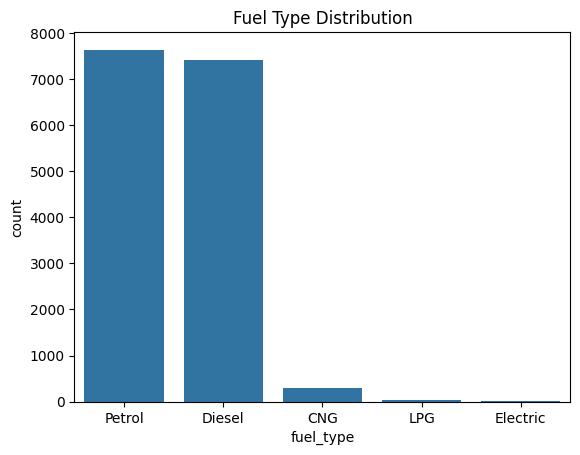

In [111]:
sns.countplot(x='fuel_type', data=df)
plt.title("Fuel Type Distribution")
plt.show()

--Shows count of Petrol, Diesel, CNG cars

--Helps understand dataset composition

--Usually Petrol dominates

# Transmission Count

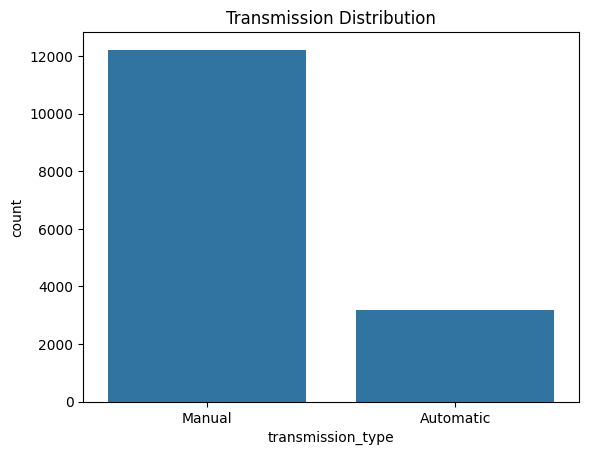

In [112]:
sns.countplot(x='transmission_type', data=df)
plt.title("Transmission Distribution")
plt.show()

--Shows Manual vs Automatic distribution

--Indicates market preference

--Manual cars usually higher in number

# Fuel Type vs Selling Price

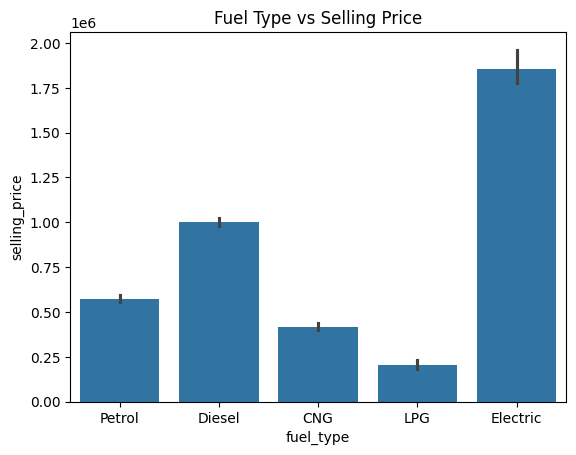

In [113]:
sns.barplot(x='fuel_type', y='selling_price', data=df)
plt.title("Fuel Type vs Selling Price")
plt.show()

--Diesel cars often have higher resale value

--Petrol cars dominate but lower price

--CNG cars may have niche behavior

# Seller Type vs selling Price

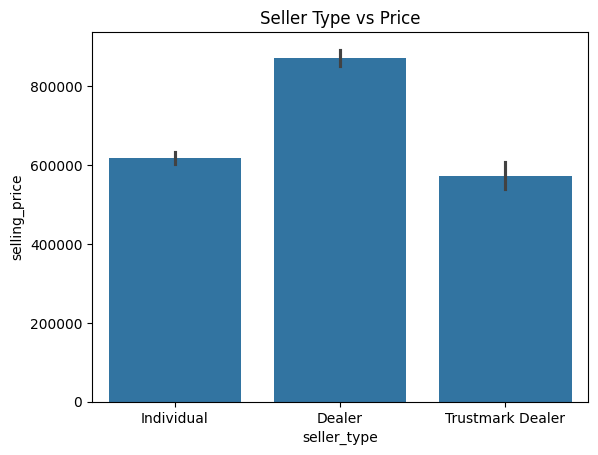

In [114]:
sns.barplot(x='seller_type', y='selling_price', data=df)
plt.title("Seller Type vs Price")
plt.show()

--Dealer cars usually priced higher than individuals

--Trust factor increases resale value

--Helps identify pricing differences

# Car Age vs Selling Price

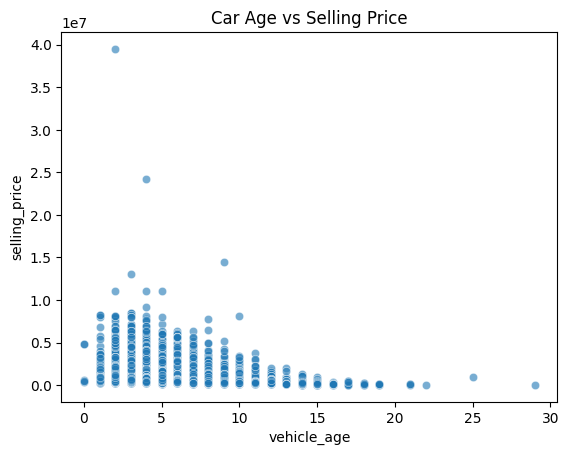

In [124]:
sns.scatterplot(x='vehicle_age', y='selling_price', data=df,alpha=0.6)
plt.title("Car Age vs Selling Price")
plt.show()

--Older cars → lower resale price

--Strong depreciation pattern visible

--Helps validate feature engineering

# Transmission + Fuel + Price

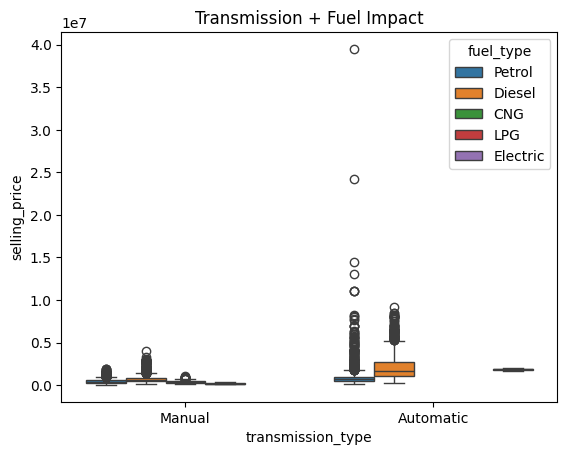

In [125]:
sns.boxplot(x='transmission_type', y='selling_price', hue='fuel_type', data=df)
plt.title("Transmission + Fuel Impact")
plt.show()

-- Combines 3 variables

--Automatic + Diesel often highest priced

--Helps deeper segmentation

# Pairplot (Overall Relationships)

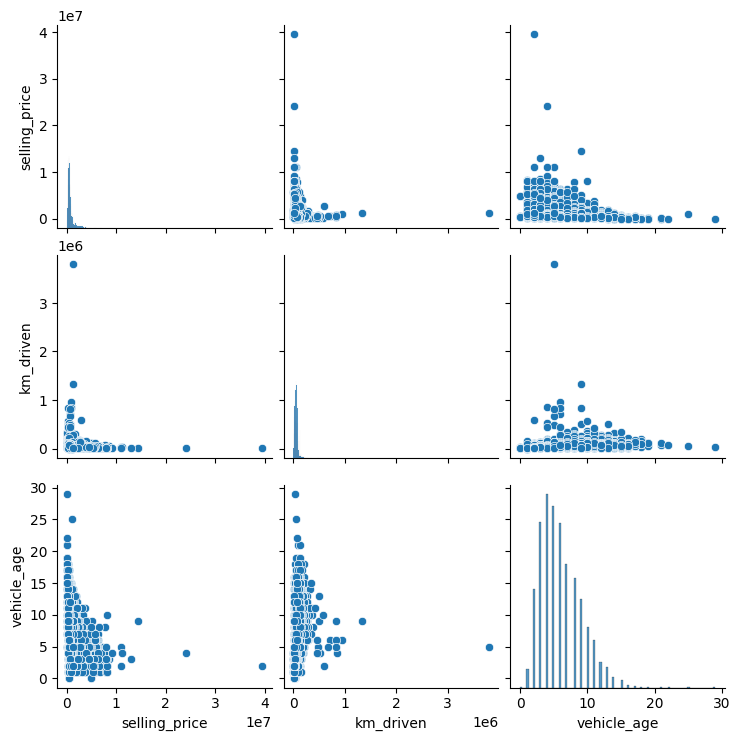

In [117]:
sns.pairplot(df[['selling_price','km_driven','vehicle_age']])
plt.show()

--Shows relationships between multiple variables

--Identifies correlation visually

--Helps detect clusters and patterns

# Correlation Heatmap

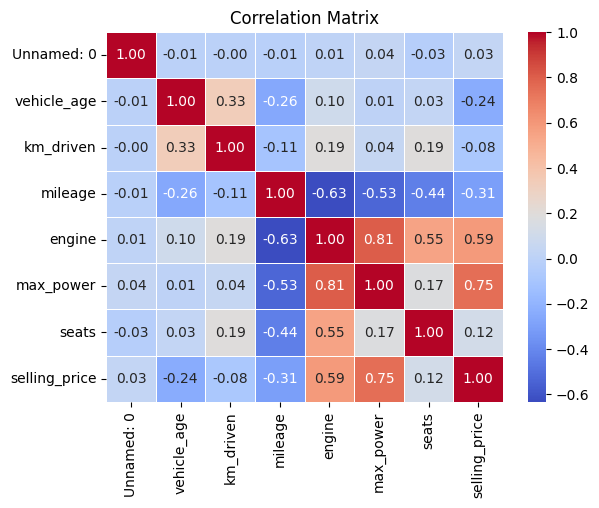

<Figure size 1200x1000 with 0 Axes>

In [118]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm',fmt='.2f',annot_kws={"size":10},linewidths=0.5)
plt.title("Correlation Matrix")
plt.figure(figsize=(12,10))
plt.show()

--Displays correlation matrix

--Strong positive: Present Price vs Selling Price

--Negative: Age vs Price


# Kms Driven Distribution (Log Scale)

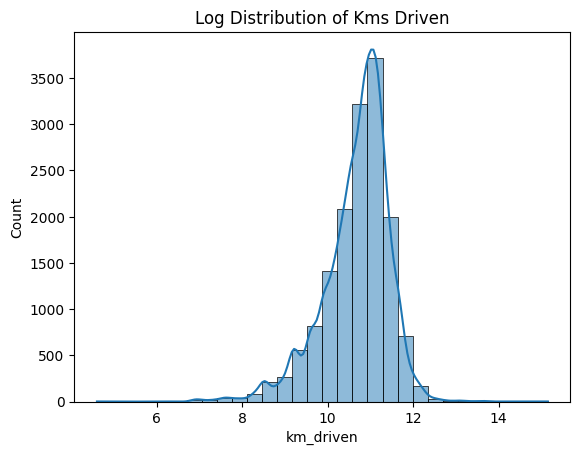

<Figure size 1000x600 with 0 Axes>

In [119]:
sns.histplot(np.log(df['km_driven']), kde=True,bins=30,linewidth=0.5)
plt.title("Log Distribution of Kms Driven")
plt.figure(figsize=(10,6))
plt.show()


-- Important for pricing model

--Normalizes skewed data

--Helps better visualization

--Reveals true distribution

# Seller Type vs Transmission

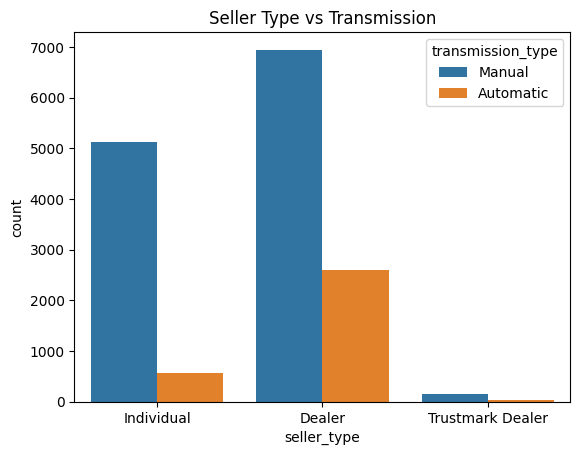

In [120]:
sns.countplot(x='seller_type', hue='transmission_type', data=df)
plt.title("Seller Type vs Transmission")
plt.show()

--Shows relationship between seller & transmission

--Dealers sell more automatic cars

--Individuals sell more manual

# Fuel Type vs Transmission

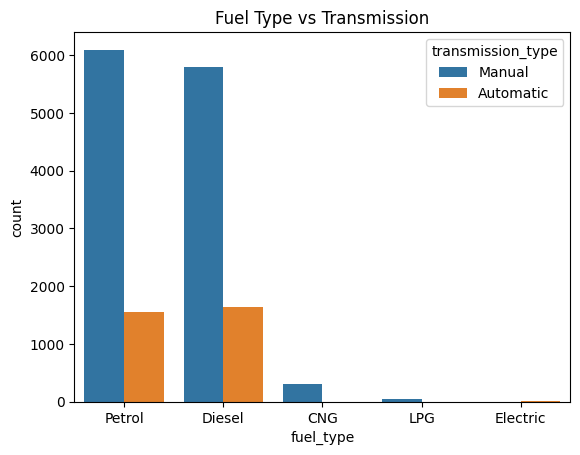

In [121]:
sns.countplot(x='fuel_type', hue='transmission_type', data=df)
plt.title("Fuel Type vs Transmission")
plt.show()

--Shows category interaction

--Petrol cars mostly manual

--Diesel may have more automatic options

# Joint Plot (Kms vs Price)

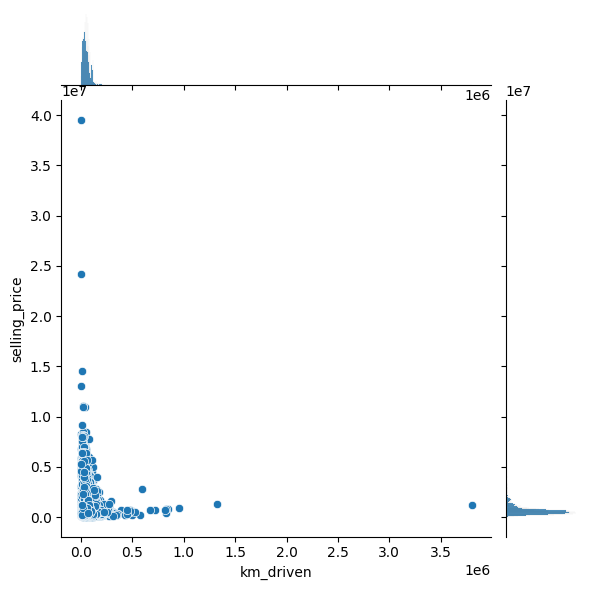

<Figure size 1200x600 with 0 Axes>

In [122]:
sns.jointplot(x='km_driven', y='selling_price', data=df, kind='scatter')
plt.figure(figsize=(12,6))
plt.show()

--Combines scatter + distribution

--Shows relationship + density

--Helps detect clusters

# Regression: Car Age vs Price

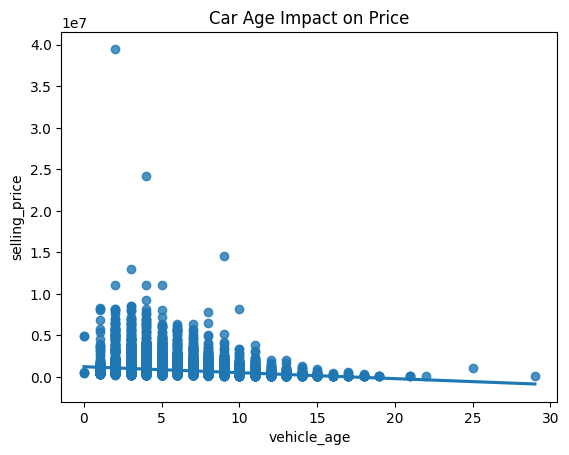

<Figure size 1000x600 with 0 Axes>

In [123]:
sns.regplot(x='vehicle_age', y='selling_price', data=df)
plt.title("Car Age Impact on Price")
plt.figure(figsize=(10,6))
plt.tight_layout()
plt.show()

--Combines scatter + distribution

--shows relationship + density

--Helps detect clusters

 # KEY BUSINESS INSIGHTS 
 
### Dealers can price cars higher due to trust factor
### Diesel vehicles are better for resale value
### Lower mileage cars should be marketed as premium
### Older cars need competitive pricing to sell

# Final Conclusion 


#### The analysis shows that car price is highly dependent on present price, car age, and kilometers driven
#### Car age and kilometers driven have a negative impact on selling price due to depreciation
#### Present price has a strong positive correlation with selling price
#### Diesel cars retain value better compared to petrol cars
#### Automatic cars and dealer-listed cars tend to have higher prices
#### Overall, the dataset shows clear patterns that can be used for price prediction modeling